In [258]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from numpy import sqrt, linspace, zeros, ones, pi, argmin, exp, argmax, sinh, sin, conj

# We start with the physical parameters for the dielectric function

In [4]:
epsilon_infinity = 11.7 # Background dielectric function (from silicon without doping)
tau = 8.1 # Scattering time in femtoseconds
omega_p = 0.7 # Plasma frequency in inverse femtoseconds

In [30]:
def epsilon_omega(omega):
    return epsilon_infinity - omega_p**2/(omega*(omega+1j/tau))

# Figure 2b (refractive index plot)

In [56]:
N = 50
omegas = linspace(0.1, 60, N) #Frequencies in Terahertz (f not omega)
epsilons = epsilon_omega(omegas*2*pi/1000) # Multiply by 2pi to get omega, divide by 1000 to go from Terahertz to inverse femtoseconds
ns = sqrt(epsilons)
n1s = ns.real
n2s = ns.imag

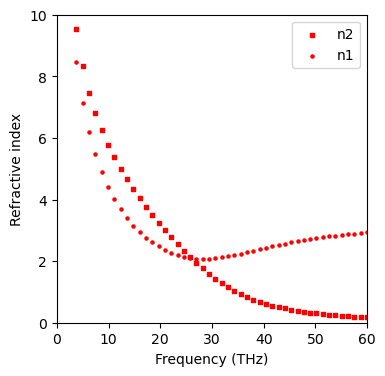

In [66]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(omegas, n2s, color="red", marker="s", s=5, label="n2")
ax.scatter(omegas, n1s, color="red", marker="o", s=5, label="n1")
ax.set_ylim(0, 10)
ax.set_xlim(0, 60);
ax.set_xlabel("Frequency (THz)");
ax.set_ylabel("Refractive index");
ax.legend();

In [71]:
# Plasma frequency 
omegas[argmin(abs(n2s-n1s))]

25.771428571428572

In [76]:
# Theoretical plasma frequency
sqrt(omega_p**2/epsilon_infinity-1/tau**2)*1000/2/pi

25.976291993896265

In [79]:
# Calculate n_1, n_2 at 27 and 5 Terahertz
n = sqrt(epsilon_omega(25.976291993896265*2*pi/1000))
print(f"At plasma frequency, n1={n.real} and n2={n.imag}")
n = sqrt(epsilon_omega(5*2*pi/1000))
print(f"At f=5THz, n1={n.real} and n2={n.imag}")

At plasma frequency, n1=2.1035697199729726 and n2=2.1035697199729726
At plasma frequency, n1=7.127155802224532 and n2=8.324065789332552


## Figure 2a (Absorption spectrum for symmetric inputs)

In [92]:
def reflection(n, k, d):
    r_num = (n**2-1)*(exp(2j*n*k*d)-1)
    r_t_denom = (n+1)**2-((n-1)**2)*exp(2j*n*k*d)
    return r_num/r_t_denom
def transmission(n, k, d):
    t_num = 4*n*exp(1j*n*k*d)
    r_t_denom = (n+1)**2-((n-1)**2)*exp(2j*n*k*d)
    return t_num/r_t_denom

In [138]:
N_omegas = 250
N_ds = 1000
omegas = linspace(0.1, 60, N_omegas) #Frequencies in Terahertz (f not omega)
c = 300 # speed of light in microns times Terhahertz
ks = omegas*2*pi/c
epsilons = epsilon_omega(omegas*2*pi/1000) # Multiply by 2pi to get omega, divide by 1000 to go from Terahertz to inverse femtoseconds
ns = sqrt(epsilons)
ds = linspace(0, 10, N_ds);

ns_reshaped = (ns.reshape((N_omegas, 1))).repeat(N_ds, 1)
ks_reshaped = (ks.reshape((N_omegas, 1))).repeat(N_ds, 1)
ds_reshaped = (ds.reshape((1, N_ds))).repeat(N_omegas, 0)
rs = reflection(ns_reshaped, ks_reshaped, ds_reshaped)
ts = transmission(ns_reshaped, ks_reshaped, ds_reshaped)
absorption = 1-(abs(rs+ts))**2

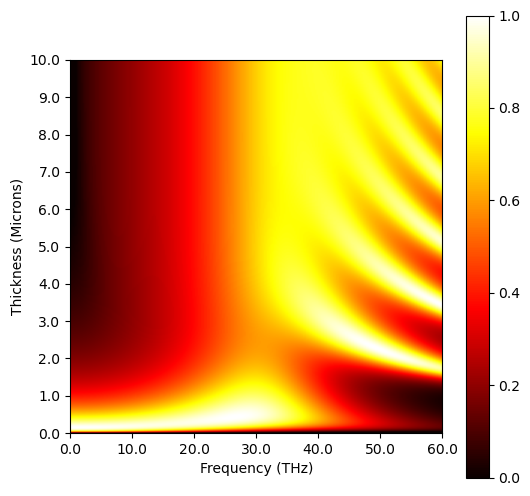

In [167]:
cmap = "hot"
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(absorption.T, cmap="hot", origin="lower", vmin=0.1, vmax=1);
ax.set_yticks(linspace(0, N_ds-1, 11), linspace(0, 10, 11))
ax.set_xticks(linspace(0, N_omegas-1, 7), linspace(0, 60, 7))
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Thickness (Microns)")

ax.set_ylim(0, N_ds-1)
ax.set_xlim(0, N_omegas-1)

ax.set_aspect(N_omegas/N_ds)
fig.colorbar(matplotlib.cm.ScalarMappable(norm=None, cmap=cmap), ax=ax);

## Figure 2b (Absorption spectrum curve)

In [169]:
d_idx_1 = argmin(abs(ds*1000 - 150))
d_idx_2 = argmin(abs(ds*1000 - 450))

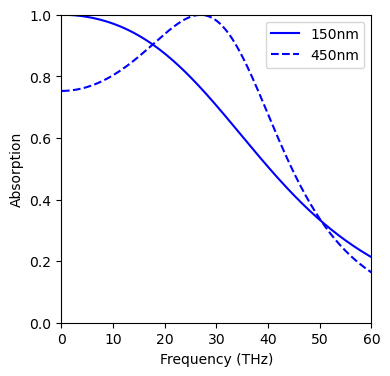

In [183]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(omegas, absorption[:, d_idx_1], color="blue", label="150nm")
ax.plot(omegas, absorption[:, d_idx_2], linestyle="dashed", color="blue", label="450nm")
ax.set_ylim(0, 1);
ax.set_xlim(0, 60);
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Absorption");
ax.legend();

## Figure 3 (Changing dopant concentration)

In [192]:
nu_min = 44.9
nu_max = 470.5 # minimum and maximum mobilities in cm^2/(Volt*seconds)
alpha = 0.719
def omega_p_of_N(N): # Gives omega_p as a function of the dopant density
    ## N should be given in units of 4*10^19 inverse cubic centimeters
    return sqrt(omega_p**2 * (N/4))
def tau_of_N(N): # Gives electron scattering time as a function of dopant density 
    nu = nu_min + (nu_max-nu_min)/(1+(N*100/2.23)**alpha)
    return nu * 0.26*0.511*10/9 # tau in femtoseconds

In [195]:
def epsilon_omega_N(omega, N):
    omega_p = omega_p_of_N(N)
    tau = tau_of_N(N)
    return epsilon_infinity - omega_p**2/(omega*(omega+1j/tau))

In [196]:
absorption_per_doping = zeros((4, N));

In [200]:
N_omegas = 250
omegas = linspace(0.1, 60, N_omegas) #Frequencies in Terahertz (f not omega)
c = 300 # speed of light in microns times Terhahertz
ks = omegas*2*pi/c
Ncs = [1, 2, 4, 7] # Dopant concentrations
d = 450/1000 # 0.45 micron thickness
for (N_c_idx, N_c) in enumerate(Ncs):
    epsilons = epsilon_omega_N(omegas*2*pi/1000, N_c) # Multiply by 2pi to get omega, divide by 1000 to go from Terahertz to inverse femtoseconds
    ns = sqrt(epsilons)
    rs = reflection(ns, ks, d)
    ts = transmission(ns, ks, d)
    absorption_per_doping[N_c_idx, :] = 1-(abs(rs+ts))**2

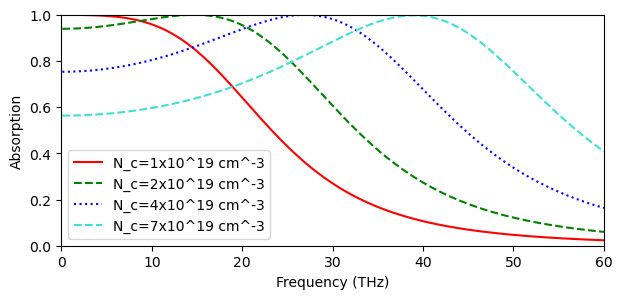

In [218]:
fig, ax = plt.subplots(figsize=(7, 3))
colors = ["red", "green", "blue", "turquoise"]
linestyles = ["solid", "dashed", "dotted", "dashed"]
for (N_c_idx, N_c) in enumerate(Ncs):
    ax.plot(omegas, absorption_per_doping[N_c_idx, :], label=f"N_c={N_c}x10^19 cm^-3", color=colors[N_c_idx], linestyle=linestyles[N_c_idx])
ax.legend()
ax.set_ylim(0, 1)
ax.set_xlim(0, 60)
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Absorption");

## Calculate absorption directly from current density in the material

In [232]:
# Electric fields in the thin film
def E_1(r, t, k, d, n):
    p = n*k
    return (1+r+t)*(exp(-1j*p*d/2) - exp(1j*p*d/2))/(exp(-1j*p*d)-exp(1j*p*d))

def E_2(r, t, k, d, n):
    p = n*k
    return (1+r+t)*(exp(1j*p*d/2) - exp(-1j*p*d/2))/(exp(1j*p*d)-exp(-1j*p*d))

In [254]:
omegas = linspace(0.1, 60, N_omegas) #Frequencies in Terahertz (f not omega)
c = 300 # speed of light in microns times Terhahertz
ks = omegas*2*pi/c
N_c = 4
d = 450/1000
epsilons = epsilon_omega_N(omegas*2*pi/1000, N_c) # Multiply by 2pi to get omega, divide by 1000 to go from Terahertz to inverse femtoseconds
ns = sqrt(epsilons)
n1s = ns.real
n2s = ns.imag

rs = reflection(ns, ks, d)
ts = transmission(ns, ks, d)
E_1s = E_1(rs, ts, ks, d, ns)
E_2s = E_2(rs, ts, ks, d, ns)

## Check that boundary conditions are satisfied

In [253]:
bc_1 = max(abs(E_1s*exp(-1j*ks*ns*d/2)+E_2s*exp(1j*ks*ns*d/2)-1-rs-ts))
bc_2 = max(abs(E_1s*exp(1j*ks*ns*d/2)+E_2s*exp(-1j*ks*ns*d/2)-1-rs-ts))
bc_3 = max(abs(ns*(E_1s*exp(-1j*ks*ns*d/2)-E_2s*exp(1j*ks*ns*d/2))-1+rs+ts))
bc_4 = max(abs(ns*(E_1s*exp(1j*ks*ns*d/2)-E_2s*exp(-1j*ks*ns*d/2))+1-rs-ts))

In [250]:
print(f"Maximum deviation of boundary conditions: {max([bc_1, bc_2, bc_3, bc_4])}")

Maximum deviation of boundary conditions: 3.805508505830686e-15


In [265]:
absorption_from_current = (n1s*(abs(E_1s)**2+abs(E_2s)**2)*sinh(n2s*ks*d) + n2s*(E_1s*conj(E_2s)+E_2s*conj(E_1s))*sin(n1s*ks*d)).real

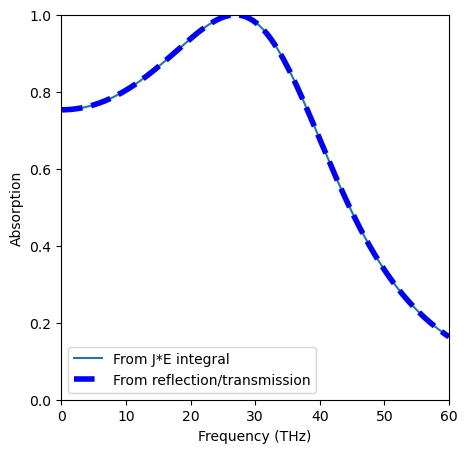

In [280]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(omegas, absorption_from_current, linestyle="solid", label="From J*E integral")
ax.plot(omegas, absorption_per_doping[2, :], linestyle="dashed", color="blue", label="From reflection/transmission", linewidth=4)
ax.set_xlim(0, 60)
ax.set_ylim(0, 1);
ax.legend();
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Absorption");